#### Precision and Recall metrics. F-measure (F1-score) - Precision və Recall göstəriciləri. F-ölçü (F1 skoru)

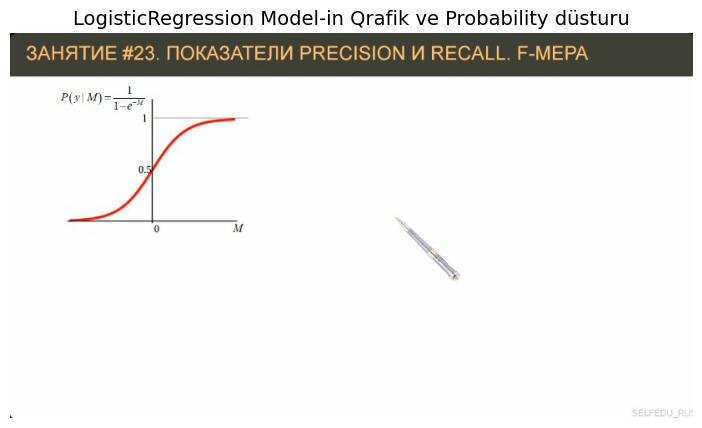

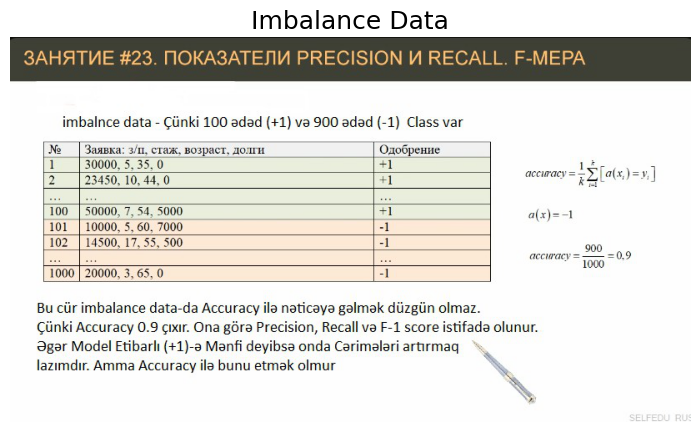

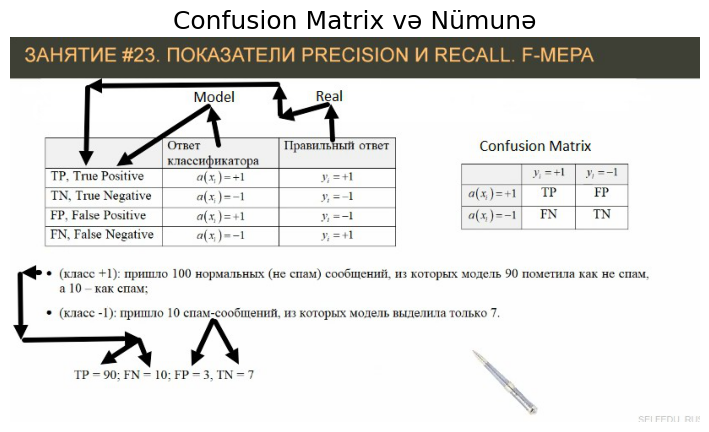

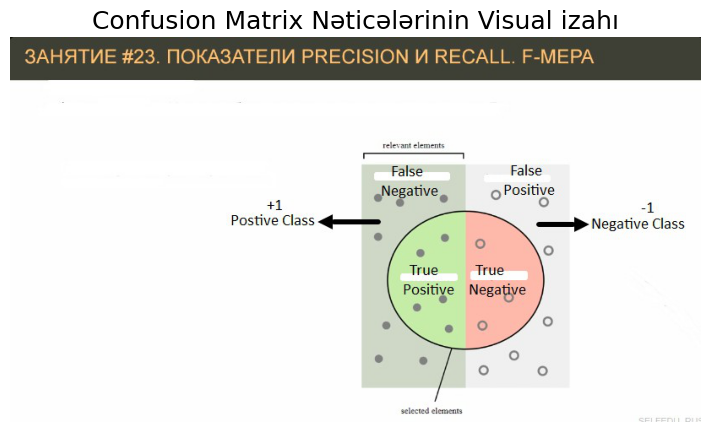

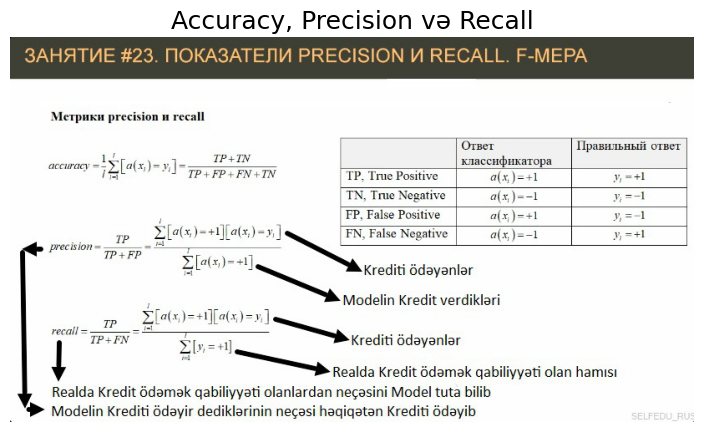

In [12]:
from PIL import Image

# Fayl yolunun əsas hissəsi
base_path = r'C:\Users\dell\Desktop\Selfedu\Pictures\ML_23_'

# Şəkilləri saxlayacağımız siyahı
image_list = []

# 1-dən 5-ə qədər olan şəkilləri dövr ilə açırıq
for i in range(1, 6):  # 1-dən 5-ə qədər
    full_path = f'{base_path}{i}.jpg'  # Fayl yolunu dinamik olaraq yaradırıq
    img = Image.open(full_path)
    image_list.append(img)  # Şəkili siyahıya əlavə edirik

# Nəticə: images siyahısında bütün yüklənmiş şəkillər olacaq

import matplotlib.pyplot as plt

# Şəkilləri göstərin
for i, image in enumerate(image_list):
    if i == 100:
        plt.figure(figsize=(8.8, 4))          
    else:     
        plt.figure(figsize=(25, 5))  # Şəkilin ölçüsü    
        
    if i < 1:
        plt.title("""LogisticRegression Model-in Qrafik ve Probability düsturu""", size='14')    
    elif i < 2:
        plt.title("""Imbalance Data""", size='18')
    elif i < 3:
        plt.title("""Confusion Matrix və Nümunə""", size='18')
    elif i < 4:
        plt.title("""Confusion Matrix Nəticələrinin Visual izahı""", size='18')
    elif i < 5:
        plt.title("""Accuracy, Precision və Recall""", size='18')        
    
    plt.imshow(image)
    plt.axis('off')  # Oxları gizlətmək üçün
    plt.show()

### Accuracy 

> **Accuracy (dəqiqlik)** — **modelin düzgün təsnif etdiyi nümunələrin bütün nümunələrə nisbətidir. Yəni, modelin nə qədər “doğru” işlədiyini göstərir.**

> **Accuracy (dəqiqlik) maşın öyrənməsi və statistika sahəsində ən sadə performans ölçülərindən biridir. O, modelin düzgün proqnoz verdiyi halların ümumi hallara nisbətini göstərir.**

<br>

**Tərifi:**

$$
\text{Accuracy} = \frac{\text{Düzgün təsnif olunan nümunələrin sayı}}{\text{Ümumi nümunələrin sayı}}
$$

<br>

**Confuison Matrix**


|                   | **Model Positive**           | **Model Negative**            |
| ----------------- | ---------------------------- | ----------------------------- |
| **Real Positive** | <div style="text-align:center">**TP**                       | <div style="text-align:center">**FN** <br> **Type II Error** |
| **Real Negative** |  <div style="text-align:center">**FP** <br> **Type I Error** | <div style="text-align:center">**TN**                        |
    
<br>
    
**Simvolik düsturla:**

$$
\text{Accuracy} = \frac{TP + TN}{TP + TN + FP + FN}
$$

Burada:

* $TP$ = True Positive (doğru müsbət)
* $TN$ = True Negative (doğru mənfi)
* $FP$ = False Positive (səhv müsbət)
* $FN$ = False Negative (səhv mənfi)


**Misal:**
100 nümunədən 90-ını düzgün proqnoz etsək, accuracy belə hesablanır:
$$
\text{Accuracy} = \frac{90}{100} = 0.9 = 90%
$$


Qısa desək: **Accuracy = Düzgünlərin faizi**.

    
    
<br>

#### **Diqqqət ediləsi nüans**
> **Qısa desək, accuracy modelin ümumi düzgünlüyünü ölçür, amma Balanssız (məsələn, 95% mənfi, 5% müsbət olan) datasetlərdə yanıltıcı ola bilər.** 
       


### Accuracy niyə problemlidir? - nəyi nəzərə almır?

**Accuracy sadəcə neçə düzgün proqnoz etdiyini ölçür:**

$$
Accuracy = \frac{TP + TN}{TP + TN + FP + FN}
$$

Yəni:

> * ❌ **Modelin özünə nə qədər əmin olduğunu (confidence/probability) nəzərə almır**
> * ❌ **Datasetin balanslı olub-olmadığını nəzərə almır**

<br>

#### **Niyə problem yaradır?**

**1. Confidence məsələsi**

* **Model 0.51 ehtimalla desin “1”**
* **Başqa model 0.99 ehtimalla desin “1”**

> ➡️ **Accuracy üçün fərqi yoxdur — ikisi də düzdür = 1 xal**

<br>

**2. Balanssız data (çox vacib!)**
Məsələn:

* **100 nəfərdən 95-i “negative”, 5-i “positive”**

> **Model hamıya “negative” desə:**

*  **Accuracy = 95%** 😄
* **Amma model heç nə öyrənməyib** 😐

<br>

#### **Ona görə nə istifadə olunur?**

**Bu problemləri həll etmək üçün:**

* **Precision**
* **Recall**
* **F1-score**
* **ROC-AUC**

**istifadə olunur.**



#### **Confusion Matrix** (qarışıqlıq matrisi) — klassifikasiya modelinin nəticələrini qiymətləndirmək üçün istifadə olunan cədvəldir. 
- #### Modelin **doğru** və **səhv** proqnozlarını 4 hissəyə bölür.

#### **📊 Confusion Matrix nəyi göstərir?**

> **Modelin dediyi ilə (Prediction) real nəticəni (Actual) müqayisə edir:**

- **Confuison Matrix**


|                   | **Model Positive**           | **Model Negative**            |
| ----------------- | ---------------------------- | ----------------------------- |
| **Real Positive** | <div style="text-align:center">**TP**                       | <div style="text-align:center">**FN** <br> **Type II Error** |
| **Real Negative** |  <div style="text-align:center">**FP** <br> **Type I Error** | <div style="text-align:center">**TN**                        |
    
<br>

#### **🔍4 əsas anlayış**

<br>
    
#### 1️⃣ **TP (True Positive)**

👉 Model **pozitiv dedi və doğrudur**

- **Real: Positive**
- **Model: Positive**
  - ✅ **Düzgün tapdı**

- 📌 **Məsələn:**
- **Xəstəlik VAR → model dedi VAR**

<br>

 #### 2️⃣ **FP (False Positive)** — **Type I Error**

👉 Model **pozitiv dedi amma səhvdir**

- **Real: Negative**
- **Model: Positive**
  - ❌ **Səhv (yalancı siqnal)**

- **📌 Məsələn:**
- **Xəstəlik YOX → model dedi VAR**   
    
    
<br>

#### 3️⃣  **TN (True Negative)**

👉 Model **negativ dedi və doğrudur**

- **Real: Negative**
- **Model: Negative**
  - **✅ Düzgün tapdı**

- **📌 Məsələn:**
- **Xəstəlik YOX → model dedi YOX**
    
<br>

#### 4️⃣ **FN (False Negative)** — **Type II Error**

👉 Model **negativ dedi amma səhvdir**

- **Real: Positive**
- **Model: Negative**
  - ❌ **Səhv (qaçırdı)**

- 📌 **Məsələn:**
- **Xəstəlik VAR → model dedi YOX**

<br>

#### 🧠 **Qısa yadda saxla:**

* **TP** → **düz pozitiv**
* **TN** → **düz negativ**
* **FP** → **yalancı pozitiv (boşuna qorxutdu 😄)**
* **FN** → **qaçırdı (ən təhlükəlisi çox vaxt budur)**

<br>

#### **⚡ Niyə vacibdir?**

> **Bu 4 dəyərdən aşağıdakı metriklər hesablanır:**

* **Precision**
* **Recall**
* **F1-score**
* **Accuracy**


### **Confusion Matrix Modelin verdiyi Nümunəni necə qiymətləndirir**



#### **Şəkildəki Verilənlər**
Burada iki sinif var:
* **Klass +1 (Normal mesajlar - Spam deyil):** **Ümumi 100 ədəd.**
    * **Model bunlardan 90-nı düzgün tapıb (normal olaraq qeyd edib).**
    * **10-nu isə səhvən "spam" kimi qeyd edib.**
* **Klass -1 (Spam mesajlar):** **Ümumi 10 ədəd.**
    * **Model bunlardan yalnız 7-ni "spam" kimi müəyyən edə bilib.**
    * **Deməli, qalan 3-nü səhvən "normal" kimi qeyd edib.**

<br>

#### **Metriklərin İzahı**
Şəklin aşağı hissəsində qeyd olunan qısaltmaların mənası budur:

* **TP (True Positive) = 90**
    * **Model müsbət sinfi (+1, yəni normal mesajı) düzgün proqnozlaşdırıb. 100 normal mesajdan 90-ı doğru tapılıb.**
* **FN (False Negative) = 10**
    * **Model müsbət sinfi (+1) səhvən mənfi (-1) kimi qeyd edib. Yəni 10 normal mesajı "spam" sanıb (Tip I səhv).**
* **TN (True Negative) = 7**
    * **Model mənfi sinfi (-1, yəni spamı) düzgün proqnozlaşdırıb. 10 spamdan 7-sini doğru tutub.**
* **FP (False Positive) = 3**
    * **Model mənfi sinfi (-1) səhvən müsbət (+1) kimi qeyd edib. Yəni 3 spam mesajı "normal" sanıb (Tip II səhv).**

<br>

#### **Riyazi Hesablama**
Bu rəqəmlər əsasında modelin dəqiqliyini ($Accuracy$) belə hesablamaq olar:

$$Accuracy = \frac{TP + TN}{TP + TN + FP + FN} = \frac{90 + 7}{100 + 10} = \frac{97}{110} \approx 88\%$$

**Xülasə:** Şəkildəki oxlar hansı rəqəmin hansı metrikə aid olduğunu göstərir. Məsələn, müsbət sinif daxilindəki səhv proqnozlar $FN$-ə, mənfi sinif daxilindəki düzgün proqnozlar isə $TN$-ə gedir.

Bu mövzu ilə bağlı hansısa konkret düsturun (məsələn, Precision və ya Recall) çıxarılışını istərdinizmi?

### **Precision düstur:**

#### **Precision (1 sinfi üçün)**:

$$
\text{Precision}_1 = \frac{TP}{TP + FP}
$$

#### **Qısa izah:**

* **TP (True Positive)** → **1 olub düzgün 1 deyilib**
* **FP (False Positive)** → **0 olub səhvən 1 deyilib**

> **Yəni Model “1” dediklərinin nə qədəri həqiqətən 1-dir.**

<br>

#### **Precision (0 sinfi üçün):**
$$
\text{Precision}_0 = \frac{TN}{TN + FN}
$$

#### **Qısa izah:**

* **TN (True Negative)** → **0 olanları düzgün 0 demək**
* **FN (False Negative)** → **1 olub səhvən 0 demək**

> **Yəni Model “0” dediklərinin nə qədəri həqiqətən 0-dır.**


### **Recall düstur** 

#### **Recall (1 sinfi üçün):** 

$$
\text{Recall}_1 = \frac{TP}{TP + FN}
$$

#### **Qısa izah:**

* **TP (True Positive)** → **1 olub düzgün 1 deyilib**
* **FN (False Negative)** → **1 olub səhvən 0 deyilib**

> **Yəni Real 1-lərin  Model tərəfindən nə qədəri düzgün tapılıb.**

<br>

#### **Recall (0 sinfi üçün):** 

$$
\text{Recall}_0 = \frac{TN}{TN + FP}
$$

#### **Qısa izah:**

* **TN (True Negative)** → **0 olub düzgün 0 deyilib**
* **FP (False Positive)** → **0 olub səhvən 1 deyilib**

> **Yəni Real 0-ların Model tərəfindən nə qədəri düzgün tapılıb.**

